# Задание

Используя модуль **datasets** библиотеки **sklearn**, загрузите базу вин (`.load_wine()`).

Используя шаблон ноутбука, выполните загрузку, подготовку и предобработку данных. Обязательное условие: разделение данных на три выборки осуществляется по шаблону (изменять параметры подготовки данных запрещается)!

Проведите серию экспериментов и добейтесь максимальной точности классификации на тестовой выборке выше 94%.

---

С помощью метода `.summary()` зафиксируйте количество параметров созданной вами нейронной сети.


## Подключение библиотек и загрузка данных

In [3]:
# Последовательная модель НС
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization

# Утилиты для to_categorical()
from tensorflow.keras import utils

# Алгоритмы оптимизации для обучения модели
from tensorflow.keras.optimizers import Adam

# Библиотека для работы с массивами
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Разделение данных на выборки
from sklearn.model_selection import train_test_split

# Для загрузки датасета
from sklearn.datasets import load_wine

# Отрисовка графиков прямо в ноутбуке
%matplotlib inline

# Загрузка базы данных о винах
x_data = load_wine()['data']              
y_data = load_wine()['target']            

print('Размерность x_data -', x_data.shape)
print('Размерность y_data -', y_data.shape)
print()
print('Данные по первому вину:', x_data[0])
print('Класс вина:', y_data[0])

Размерность x_data - (178, 13)
Размерность y_data - (178,)

Данные по первому вину: [1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
 2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
Класс вина: 0


## Описание базы

1. Датасет состоит из набора данных о винах и их классах.
2. Данные по одному вину хранятся в numpy-массиве `x_data`: (`13` параметров).
3. В датасете `3` класса вин: `y_data`.
4. Количество примеров: `178`.

## Подготовка данных

In [4]:
# Перевод классов в one-hot encoding
y_data = utils.to_categorical(y_data, 3)

# Разделение данных на общую и тестовую выборки
x_all, x_test, y_all, y_test = train_test_split(
    x_data, y_data, test_size=0.1, shuffle=True, random_state=6
)

# Разделение общей выборки на обучающую и проверочную
x_train, x_val, y_train, y_val = train_test_split(
    x_all, y_all, test_size=0.1, shuffle=True, random_state=6
)

# Вывод размерностей
print('Обучающая выборка x_train:', x_train.shape)
print('Обучающая выборка y_train:', y_train.shape)
print()
print('Проверочная выборка x_val:', x_val.shape)
print('Проверочная выборка y_val:', y_val.shape)

Обучающая выборка x_train: (144, 13)
Обучающая выборка y_train: (144, 3)

Проверочная выборка x_val: (16, 13)
Проверочная выборка y_val: (16, 3)


## Создание модели

In [10]:
model = Sequential()
model.add(Dense(128, input_dim=x_train.shape[1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,995 (50.76 KB)

 Trainable params: 12,611 (49.26 KB)

 Non-trainable params: 384 (1.50 KB)

## Обучение модели

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.4236 - loss: 1.1408 - val_accuracy: 0.2500 - val_loss: 2.5333
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6111 - loss: 0.8049 - val_accuracy: 0.2500 - val_loss: 2.9882
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6736 - loss: 0.7114 - val_accuracy: 0.2500 - val_loss: 2.8652
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7222 - loss: 0.6272 - val_accuracy: 0.2500 - val_loss: 2.5748
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6944 - loss: 0.6639 - val_accuracy: 0.2500 - val_loss: 2.1309
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7292 - loss: 0.6096 - val_accuracy: 0.2500 - val_loss: 1.8017
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.6316 - val_accuracy: 0.2500 - val_loss: 1.5413
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7639 - loss: 0.5641 - val_accuracy: 0.3125 - val_loss: 1.2866


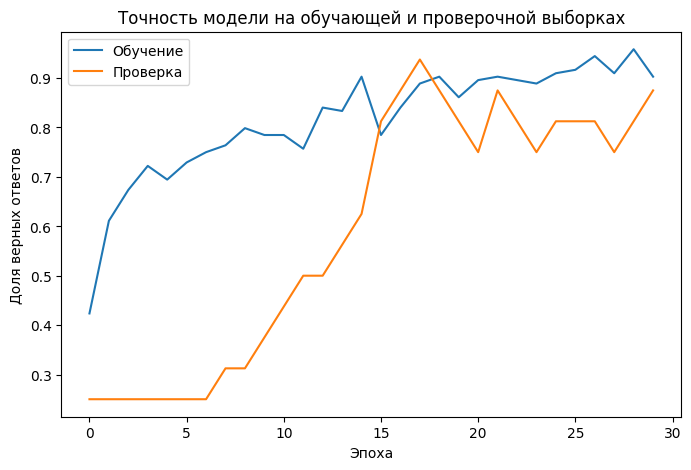

In [11]:
# Обучение модели
history = model.fit(
    x_train, y_train,
    batch_size=16,
    epochs=30,
    validation_data=(x_val, y_val),
    verbose=1
)

# График точности (train vs validation)
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Обучение')
plt.plot(history.history['val_accuracy'], label='Проверка')
plt.xlabel('Эпоха')
plt.ylabel('Доля верных ответов')
plt.title('Точность модели на обучающей и проверочной выборках')
plt.legend()
plt.show()

## Оценка на тестовой выборке

In [13]:
# Оценка модели на тестовой выборке
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Доля верных ответов на тестовых данных: {test_acc:.4f}')

Доля верных ответов на тестовых данных: 0.9444
